In [21]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [22]:
from sklearn.datasets import load_iris
df = load_iris()

In [23]:
print(df['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [24]:
X = pd.DataFrame(df.data, columns= df.feature_names)
Y = df.target 
X,Y

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 array([0, 0, 0, 0, 0, 0,

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

#### Decision Tree Regressor without Hyperparameter-Tuning 

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
regressor = DecisionTreeRegressor()
regressor.fit(X_train, Y_train)
y_pred = regressor.predict(X_test)
score = r2_score(y_pred, Y_test)
print(score)

1.0


[Text(0.3076923076923077, 0.9285714285714286, 'X[3] <= 0.8\nsquared_error = 0.658\nsamples = 120\nvalue = 0.992'),
 Text(0.23076923076923078, 0.7857142857142857, 'squared_error = 0.0\nsamples = 40\nvalue = 0.0'),
 Text(0.38461538461538464, 0.7857142857142857, 'X[2] <= 4.75\nsquared_error = 0.25\nsamples = 80\nvalue = 1.488'),
 Text(0.15384615384615385, 0.6428571428571429, 'X[3] <= 1.65\nsquared_error = 0.026\nsamples = 37\nvalue = 1.027'),
 Text(0.07692307692307693, 0.5, 'squared_error = 0.0\nsamples = 36\nvalue = 1.0'),
 Text(0.23076923076923078, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 2.0'),
 Text(0.6153846153846154, 0.6428571428571429, 'X[3] <= 1.75\nsquared_error = 0.103\nsamples = 43\nvalue = 1.884'),
 Text(0.38461538461538464, 0.5, 'X[2] <= 4.95\nsquared_error = 0.25\nsamples = 8\nvalue = 1.5'),
 Text(0.3076923076923077, 0.35714285714285715, 'squared_error = 0.0\nsamples = 2\nvalue = 1.0'),
 Text(0.46153846153846156, 0.35714285714285715, 'X[3] <= 1.55\nsquared_error = 0.2

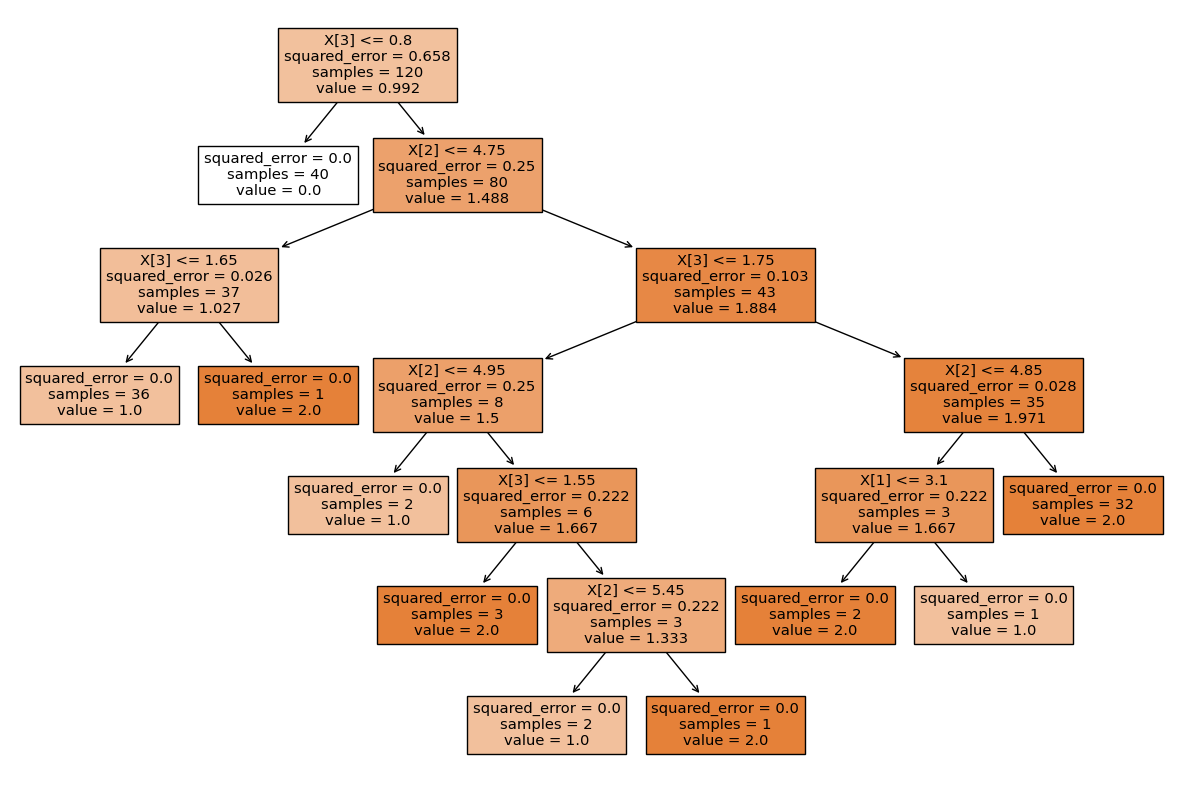

In [33]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(regressor,filled = True)

#### Decision Tree Regressor with HyperParameter-Tuning

In [27]:
parameter = {
    'criterion' : ['squared-error', 'friedman-mse', 'absolute-error', 'poisson'],
    'splitter' : ['best','random'],
    'max_depth' : [1,2,3,4,5,6,7,8,9,10,11,12,13],
    'max_features' : ['auto', 'sqrt', 'log2']
}

In [28]:
regressor2 = DecisionTreeRegressor()

In [29]:
from sklearn.model_selection import GridSearchCV
regressorcv = GridSearchCV(regressor2, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')
regressorcv.fit(X_train, Y_train)

c:\Users\Amreet\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
1170 fits failed out of a total of 1560.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
390 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Amreet\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Amreet\anaconda3\lib\site-packages\sklearn\tree\_classes.py", line 1315, in fit
    super().fit(
  File "c:\Users\Amreet\anaconda3\lib\site-packages\sklearn\tree\_classes.py", line 356, in fit
    criterion = CRITERIA_REG[self.criterion](self.n_outputs_, n_samples)
KeyError: 'squared-e

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared-error', 'friedman-mse',
                                       'absolute-error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [30]:
regressorcv.best_params_

{'criterion': 'poisson',
 'max_depth': 10,
 'max_features': 'auto',
 'splitter': 'random'}

In [31]:
y_pred = regressorcv.predict(X_test)

In [32]:
r2_score(y_pred, Y_test)

0.906776263031275